In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch import nn
from typing import Any, Dict, Optional, Union
from tqdm import tqdm

In [2]:
from causalflows.flows import CausalMAF, CausalNSF
from causalflows.scms import SCM, CausalEquations

In [3]:
cfg = {
    'hidden_dims': [32, 32],
    'lr': 1e-3,
    'batch_size': 256,
    'epochs': 1000,
}

In [4]:
class MyTriangleEqs(CausalEquations): # ONLY FOR EXAMPLE
    def __init__(self):
        functions = [
            lambda u1: u1 + 0.0,
            lambda x1, u2: x1 + u2,
            lambda x1, x2, u3: 0.25 * x1 + 0.75 * x2 + u3,
        ]
        inverses = [
            lambda x1: x1 - 0.0,
            lambda x1, x2: x2 - x1,
            lambda x1, x2, x3: x3 - 0.75 * x2 - 0.25 * x1,
        ]

        super().__init__(functions, inverses)

    @property
    def adjacency(self):
        return torch.tensor((
            (0, 0, 0),
            (1, 0, 0),
            (1, 1, 0),
        )).bool()

In [5]:
scm = SCM(equations=MyTriangleEqs(), base='std-gaussian')
adjacency = scm.adjacency

def generate_data(size: int):
    return scm.sample((size,))

In [6]:

batch_size = 2048

train_size = 10000
train_data = generate_data(train_size)

test_size = int(train_size * 0.1)
test_data = generate_data(test_size)

# Note that, when training with a dataset that is a df, we need to convert it to a tensor
# train_data = torch.tensor(train_data.to_numpy(), dtype=torch.float32)
# test_data = torch.tensor(test_data.to_numpy(), dtype=torch.float32)

def create_df(tensors_dict):
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        df = pd.DataFrame(x.numpy(), columns=[f'$x_{j}$' for j in range(x.shape[1])])
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df

In [8]:
adjacency

tensor([[False, False, False],
        [ True, False, False],
        [ True,  True, False]])

In [ ]:
features = 3
context = 0

flow = CausalNSF(features, context, adjacency=adjacency, hidden_features=cfg['hidden_dims'])

In [16]:
TensorLike = Union[torch.Tensor, Dataset]

def _make_loader(data: TensorLike, batch_size: int, shuffle: bool) -> DataLoader:
    if isinstance(data, torch.Tensor):
        data = TensorDataset(data)
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

@torch.no_grad()
def _eval_nll(flow: nn.Module, loader: DataLoader, device: torch.device) -> float:
    flow.eval()
    total, count = 0.0, 0
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        x = x.to(device)
        nll = -flow().log_prob(x)  # [B]
        total += float(nll.sum().item())
        count += x.shape[0]
    return total / max(count, 1)

def fit(
    flow: nn.Module,
    train_data: TensorLike,
    val_data: Optional[TensorLike] = None,
    *,
    lr: float = 1e-3,
    batch_size: int = 256,
    epochs: int = 100,
    device: Optional[torch.device] = None,
    print_every: int = 1,
) -> Dict[str, Any]:
    """
    Minimal training loop for a flow model with .log_prob(x).

    Args:
        flow: nn.Module implementing log_prob(x) -> [B].
        train_data: Dataset or Tensor [N, D].
        val_data: optional Dataset or Tensor for validation.
        lr, batch_size, epochs: training hyperparameters (explicitly here as requested).
        device: optional torch.device; defaults to 'cuda' if available else 'cpu'.

    Returns:
        history dict with per-epoch train/val NLL.
    """
    dev = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    flow.to(dev)

    train_loader = _make_loader(train_data, batch_size, shuffle=True)
    val_loader = _make_loader(val_data, batch_size, shuffle=False) if val_data is not None else None

    optim = torch.optim.Adam(flow.parameters(), lr=lr)

    history = {"train_nll": [], "val_nll": [] if val_loader is not None else None}

    for epoch in tqdm(range(1, epochs + 1)):
        flow.train()
        running, seen = 0.0, 0

        for batch in train_loader:
            x = batch[0] if isinstance(batch, (tuple, list)) else batch
            x = x.to(dev, non_blocking=True)

            optim.zero_grad(set_to_none=True)
            loss = -flow().log_prob(x).mean()  # mean NLL over batch
            loss.backward()
            optim.step()

            running += float(loss.item()) * x.size(0)
            seen += x.size(0)

        train_nll = running / max(seen, 1)
        history["train_nll"].append(train_nll)

        if val_loader is not None:
            val_nll = _eval_nll(flow, val_loader, dev)
            history["val_nll"].append(val_nll)
            if epoch % print_every == 0:
                print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}  val_nll={val_nll:.4f}")
        else:
            if epoch % print_every == 0:
                print(f"[{epoch:03d}/{epochs:03d}] train_nll={train_nll:.4f}")

    return history

In [17]:
history = fit(
    flow,
    train_data,
    val_data=test_data,
    lr=cfg['lr'],
    batch_size=cfg['batch_size'],
    epochs=cfg['epochs'],
    print_every=100,
)

[100/1000] train_nll=4.2641  val_nll=4.2748
[200/1000] train_nll=4.2581  val_nll=4.2825
[300/1000] train_nll=4.2540  val_nll=4.2853
[400/1000] train_nll=4.2526  val_nll=4.2963
[500/1000] train_nll=4.2490  val_nll=4.3014
[600/1000] train_nll=4.2448  val_nll=4.3061
[700/1000] train_nll=4.2441  val_nll=4.3070
[800/1000] train_nll=4.2425  val_nll=4.3140
[900/1000] train_nll=4.2391  val_nll=4.3122
[1000/1000] train_nll=4.2380  val_nll=4.3182


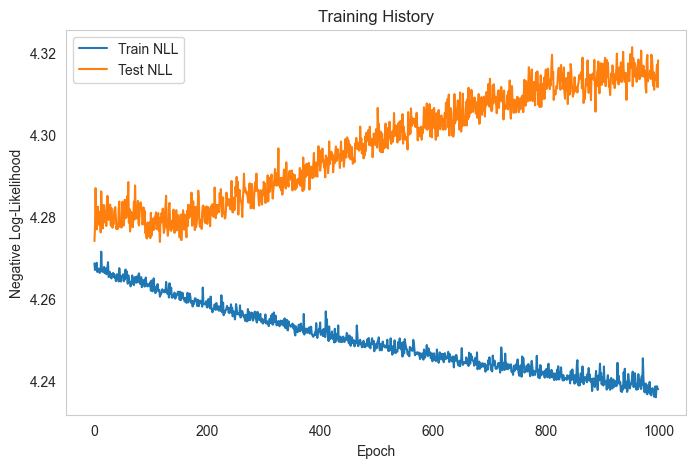

In [19]:
# plot history
plt.figure(figsize=(8, 5))
plt.plot(history['train_nll'], label='Train NLL')
plt.plot(history['val_nll'], label='Test NLL')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training History')
plt.legend()
plt.grid()
plt.show()

In [20]:
def plot_data(tensors_dict):
    df = create_df(tensors_dict)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    g.map_lower(sns.kdeplot, common_norm=False)
    g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    g.add_legend()
    plt.show()



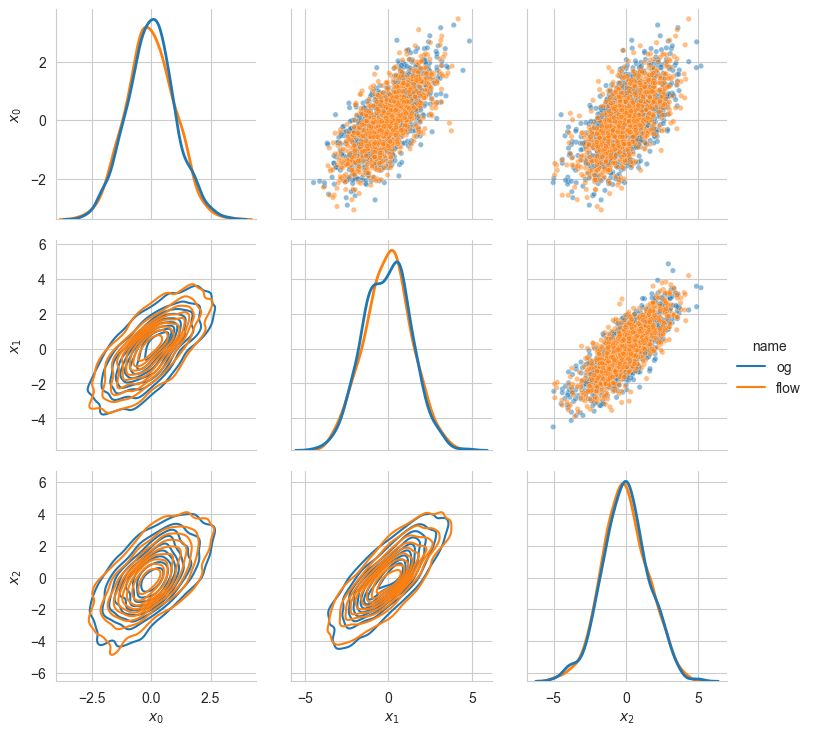

In [21]:
gen_data = flow().sample([test_size]) # ONLY FOR EXAMPLE
plot_data({'og': test_data, 'flow': gen_data}) # ONLY FOR EXAMPLE

In [22]:
def generate_int_data(size: int, index, value): # ONLY FOR EXAMPLE
    return scm.sample_interventional(index, value, (size,))
true_int_data = generate_int_data(test_size, 1, 2.5)

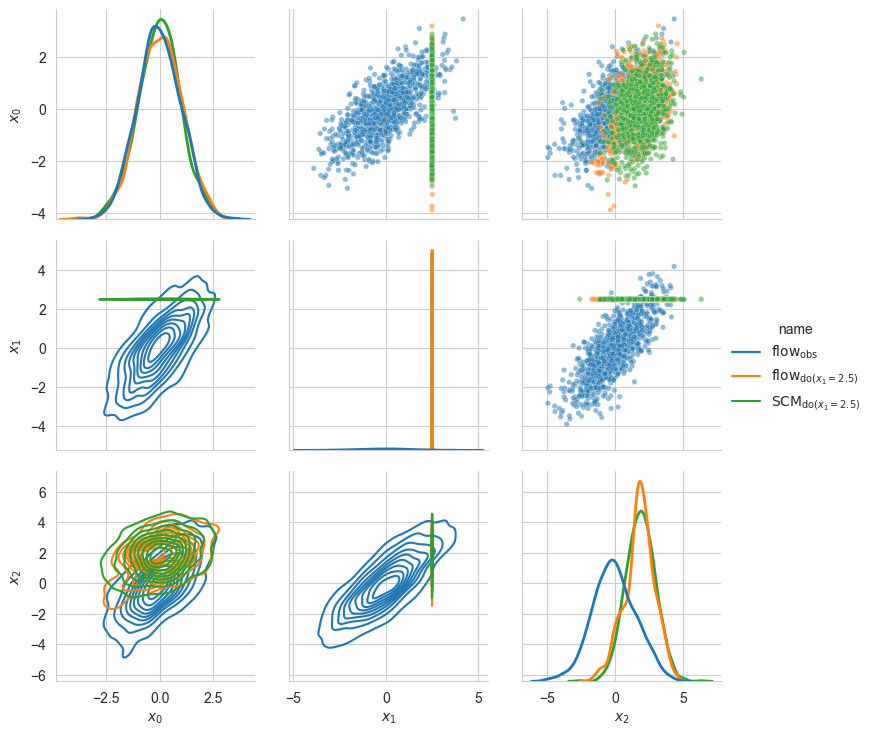

In [23]:
int_data = flow().sample_interventional(index=1, value=2.5, sample_shape=(test_size,))

int_data += torch.randn((test_size, 3)) * 0.01
true_int_data += torch.randn((test_size, 3)) * 0.01

plot_data({
    r'$\text{flow}_\text{obs}$': gen_data,
    r'$\text{flow}_{\mathrm{do}(x_1 = 2.5)}$': int_data,
    r'$\text{SCM}_{\mathrm{do}(x_1 = 2.5)}$': true_int_data,
})


In [24]:
# ATE computation
index_intervention = 1 # x1
index_outcome = 2 # x2
intervention_values = [0.5, 2.5]




In [28]:
# real ate
def compute_true_ate(index_intervention, intervention_values, index_outcome, size):
    mean_0 = scm.sample_interventional(
        index=index_intervention,
        value=intervention_values[0],
        sample_shape=(size,),
    )[:, index_outcome].mean().item()

    mean_1 = scm.sample_interventional(
        index=index_intervention,
        value=intervention_values[1],
        sample_shape=(size,),
    )[:, index_outcome].mean().item()

    return mean_1 - mean_0

In [26]:
mean_0 = flow().sample_interventional(
    index=index_intervention,
    value=intervention_values[0],
    sample_shape=(test_size,),
).mean(dim=0)[index_outcome].item()

mean_1 = flow().sample_interventional(
    index=index_intervention,
    value=intervention_values[1],
    sample_shape=(test_size,),
).mean(dim=0)[index_outcome].item()

ate_flow = mean_1 - mean_0
print(f"Estimated ATE by CausalNSF: {ate_flow:.4f}")




Estimated ATE by CausalNSF: 1.4932


In [29]:
print(f"True ATE by SCM: {compute_true_ate(index_intervention, intervention_values, index_outcome, test_size):.4f}")  # ONLY FOR EXAMPLE

True ATE by SCM: 1.4941
